# PCA Eigenfaces Lab

## Math Seminar  

**You will:**
1. Build an eigenfaces basis from the **Yale Face Database** (real photos of 15 people).  
2. Reconstruct a face using the top $r$ principal components.  
3. Upload **your own face** and see it approximated as a linear combination of eigenfaces.  
4. Reconstruct a **non‑face** (e.g., coffee) using the same face basis and compare.

> This follows the classic **eigenfaces** procedure: vectorize mean‑subtracted faces into a matrix $X$, compute SVD $X_c = U\Sigma V^T$, and use the eigenfaces (columns of $U$) for projection & reconstruction.

## Learning goals
- Explain why **centering** is required for PCA and form $X_c$.
- Compute PCA via **economy SVD** and interpret $U, \Sigma, V$.
- Use **eigenfaces** (columns of $U$) to project and reconstruct:  
  $\hat{x} = \mu + U_r U_r^T (x - \mu)$.
- Analyze **variance explained** and **reconstruction error** vs. $r$.

## Background: From SVD Image Compression to Eigenfaces

In the previous SVD lab, you decomposed a **single image** $A \in \mathbb{R}^{m \times n}$ and discovered that keeping just the top $k$ singular values gives a great approximation:

$$A_k = U_k \Sigma_k V_k^T \approx A$$

That was **compressing one image**. This lab takes the same SVD idea in a completely different direction.

**New question:** What if we have a whole *collection* of face images? Can SVD reveal the shared patterns — the "building blocks" — that all faces have in common?

**The idea:**
1. Flatten each face image into a long vector (just list all pixels in a row).
2. Stack all face vectors as **columns** of a big data matrix $X$.
3. Center the data by subtracting the **mean face** $\mu$.
4. Compute the SVD of the centered matrix: $X_c = U \Sigma V^T$.

The columns of $U$ are now the **eigenfaces** — an orthonormal set of "basis faces" that capture the dominant patterns of variation (lighting, face shape, expression) across the whole dataset.

**Connection to the SVD lab:** In that lab, the singular values told you which rank-1 pieces of a single image matter most. Here, the singular values tell you which **face patterns** explain the most variation across all faces. Same math, different interpretation!

**Why center?** PCA finds directions of maximum *variance*. Without subtracting the mean, the first principal component just points toward the average face — not very informative. Centering ensures we discover how faces *differ* from the average.

In [1]:
# %% [code] Setup
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

from skimage import data, color, transform, io
from PIL import Image
import requests
from io import BytesIO

np.random.seed(0)
plt.rcParams['figure.figsize'] = (6,4)

def show_grid(images, titles=None, ncols=6, cmap='gray', vmin=0, vmax=1, suptitle=None):
    n = len(images)
    nrows = int(ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            ax.imshow(images[i], cmap=cmap, vmin=vmin, vmax=vmax)
            if titles is not None and i < len(titles):
                ax.set_title(titles[i], fontsize=8)
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()


def to_gray01(img):
    if img.ndim == 3:
        img = color.rgb2gray(img)
    img = img.astype(float)
    if img.max() > 1:
        img = img/255.0
    return img

## 1) The Yale Face Database

The [Yale Face Database](https://vision.ucsd.edu/datasets/yale-face-database) contains **165 grayscale photographs** of **15 people**, each photographed under 11 different conditions (different lighting, expressions, and with/without glasses). This gives us a realistic set of face images to build our eigenfaces basis from.

We load all 165 images from the course GitHub repository and resize them to $128 \times 96$ pixels.

### Images as vectors

Each grayscale image is an $h \times w$ array of pixel intensities (values between 0 and 1). We **reshape** (flatten) each image into a column vector $x_i \in \mathbb{R}^d$ where $d = h \cdot w$. In this lab, $h = 128$ and $w = 96$, so each face becomes a vector in $\mathbb{R}^{12288}$.

We then stack all $n = 165$ face vectors as columns to form the **data matrix**:

$$X = \begin{bmatrix} | & | & & | \\ x_1 & x_2 & \cdots & x_{165} \\ | & | & & | \end{bmatrix} \in \mathbb{R}^{12288 \times 165}$$

Each column is one face. Each row corresponds to one pixel position across all faces.

Loading Yale Face Database...
  Loaded subject01 (1/15)
  Loaded subject02 (2/15)
  Loaded subject03 (3/15)
  Loaded subject04 (4/15)
  Loaded subject05 (5/15)
  Loaded subject06 (6/15)
  Loaded subject07 (7/15)
  Loaded subject08 (8/15)
  Loaded subject09 (9/15)
  Loaded subject10 (10/15)
  Loaded subject11 (11/15)
  Loaded subject12 (12/15)
  Loaded subject13 (13/15)
  Loaded subject14 (14/15)
  Loaded subject15 (15/15)

Total: 165 images, 15 subjects, resized to 128x96


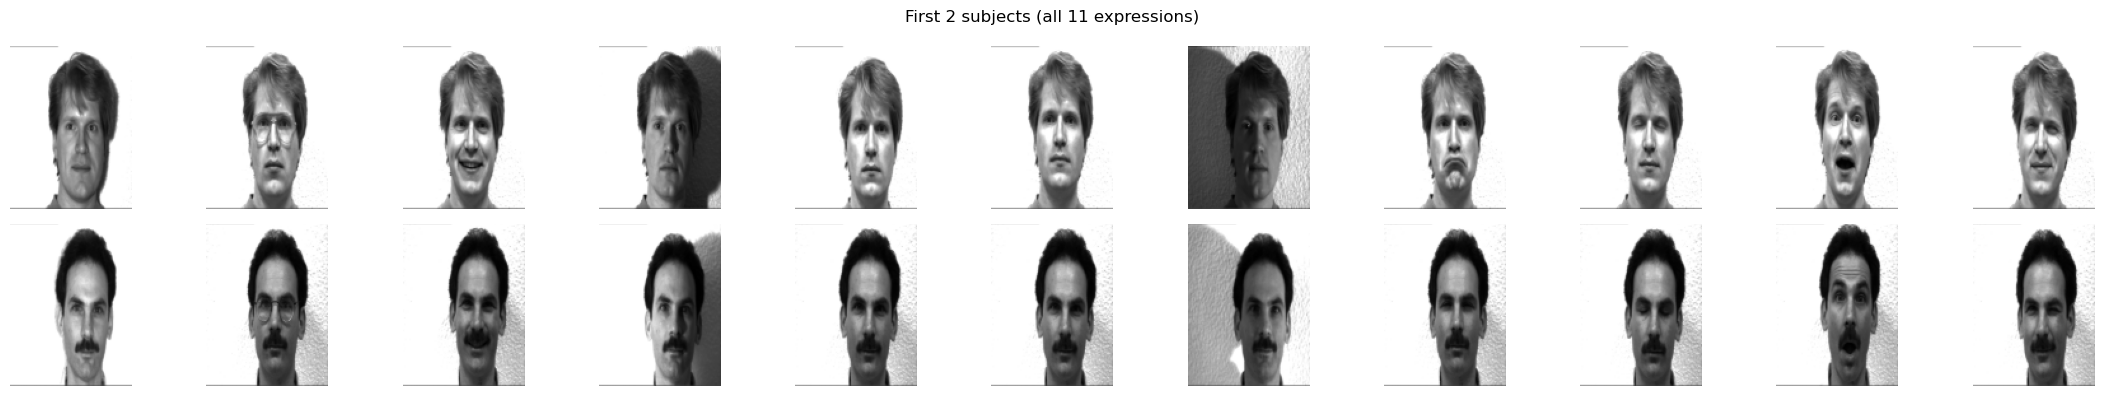

In [2]:
# %% [code] Load the Yale Face Database from GitHub
base_url = "https://raw.githubusercontent.com/LongBaoNguyen/longbaonguyen.github.io/master/courses/apcsp/datasets/yale_faces/"

subjects = [f"subject{i:02d}" for i in range(1, 16)]
expressions = ["centerlight", "glasses", "happy", "leftlight", "noglasses",
               "normal", "rightlight", "sad", "sleepy", "surprised", "wink"]

H, W = 128, 96

faces = []
labels = []
print("Loading Yale Face Database...")
for sid, subj in enumerate(subjects):
    for expr in expressions:
        url = base_url + f"{subj}.{expr}"
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("L")
        img = np.asarray(img).astype(np.float64) / 255.0
        img = transform.resize(img, (H, W), anti_aliasing=True)
        faces.append(img)
        labels.append(sid)
    print(f"  Loaded {subj} ({sid+1}/15)")

faces = np.array(faces)
labels = np.array(labels)
n, H, W = faces.shape
X = faces.reshape(n, -1).T     # d × n
print(f"\nTotal: {faces.shape[0]} images, {len(subjects)} subjects, resized to {H}x{W}")
show_grid(faces[:22], ncols=11, suptitle='First 2 subjects (all 11 expressions)')

In [3]:
faces.shape


(165, 128, 96)

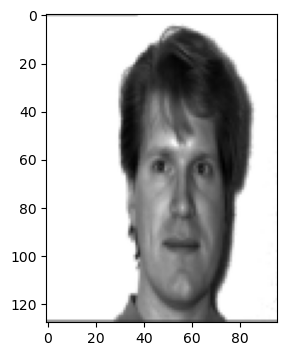

In [6]:
plt.imshow(faces[0], cmap="gray")

## 2) PCA via economy SVD

We compute the **mean face** $\mu = \frac{1}{n}\sum_{i=1}^n x_i$ and subtract it from every column:

$$X_c = X - \mu \mathbf{1}^T$$

Then we compute the **economy SVD** of the centered matrix:

$$X_c = U \Sigma V^T$$

where $U \in \mathbb{R}^{d \times n}$, $\Sigma \in \mathbb{R}^{n \times n}$, and $V^T \in \mathbb{R}^{n \times n}$.

**Interpreting the factors:**
- **Columns of $U$** (the **eigenfaces**): an orthonormal set of "basis faces" ordered by importance. They form an orthonormal basis for $\text{Col}(X_c)$.
- **$\Sigma$**: diagonal matrix of singular values $\sigma_1 \ge \sigma_2 \ge \cdots$. Larger $\sigma_k$ means the $k$-th eigenface captures more variance.
- **$V^T$**: the rows encode how much each training image "uses" each eigenface.
- **Variance explained** by the $k$-th component: $\frac{\sigma_k^2}{\sum_i \sigma_i^2}$.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


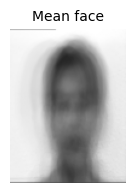

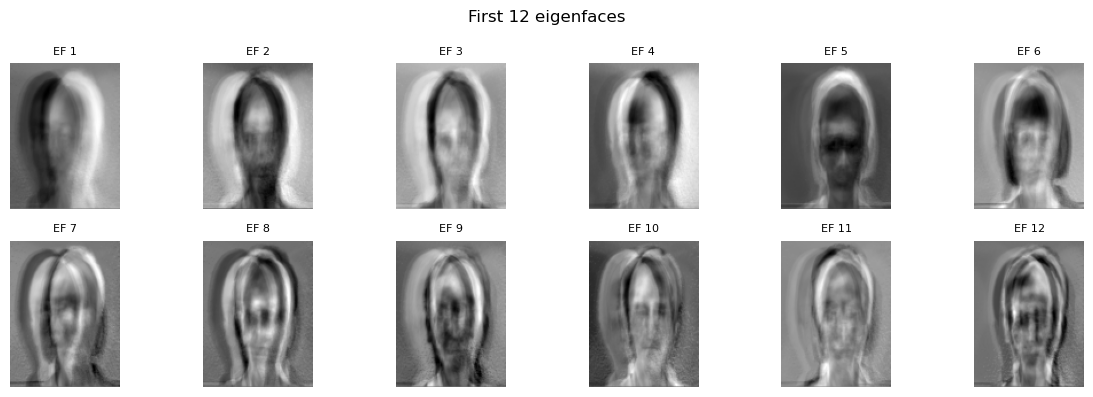

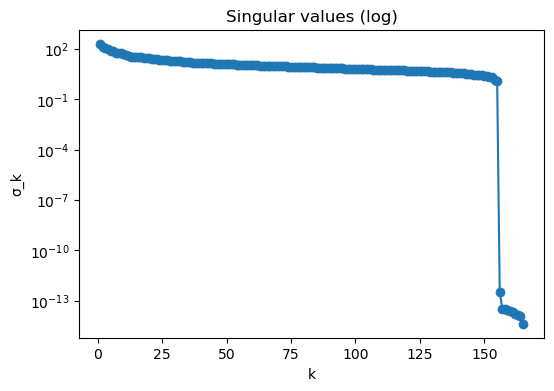

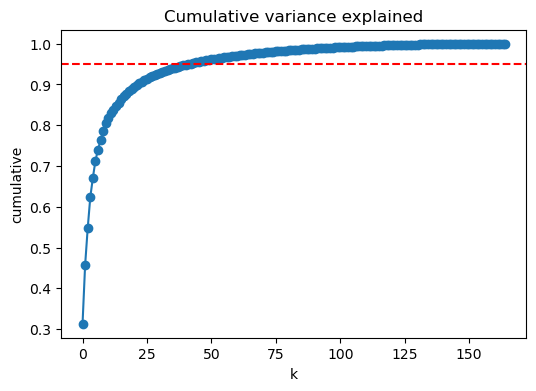

In [7]:
# %% [code] Compute SVD and inspect eigenfaces
n, H, W = faces.shape
X = faces.reshape(n, -1).T     # d × n
mu = X.mean(axis=1, keepdims=True)
Xc = X - mu
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

mean_face = mu.reshape(H, W)
eigenface_imgs = [U[:,i].reshape(H,W) for i in range(12)]

# Show mean face separately (range [0,1])
plt.figure(figsize=(2,2))
plt.imshow(mean_face, cmap='gray', vmin=0, vmax=1)
plt.title('Mean face', fontsize=10); plt.axis('off'); plt.show()

# Show eigenfaces with auto-scaled range (they have negative values)
show_grid(eigenface_imgs, titles=[f'EF {i+1}' for i in range(12)],
          ncols=6, vmin=None, vmax=None, suptitle='First 12 eigenfaces')

explained = (S**2)/np.sum(S**2)
plt.figure(); plt.semilogy(np.arange(1,len(S)+1), S, 'o-')
plt.title('Singular values (log)'); plt.xlabel('k'); plt.ylabel('σ_k'); plt.show()
plt.figure(); plt.plot(np.cumsum(explained), 'o-'); plt.axhline(0.95, color='r', ls='--')
plt.title('Cumulative variance explained'); plt.xlabel('k'); plt.ylabel('cumulative'); plt.show()

## 3) Reconstruction as orthogonal projection

This is the key connection to what you learned about **orthogonal projection**!

Let $W = \text{span}\{u_1, u_2, \ldots, u_r\}$ be the subspace spanned by the first $r$ eigenfaces. Since the columns of $U_r$ are orthonormal, the **orthogonal projection** of a centered vector $(x - \mu)$ onto $W$ is:

$$\text{proj}_W(x - \mu) = U_r U_r^T (x - \mu)$$

Recall from class: if $\{u_1, \ldots, u_r\}$ is an orthonormal basis for $W$, then

$$\text{proj}_W(v) = (u_1 \cdot v)\, u_1 + (u_2 \cdot v)\, u_2 + \cdots + (u_r \cdot v)\, u_r = U_r U_r^T v$$

The **reconstruction** adds back the mean:

$$\hat{x} = \mu + U_r U_r^T (x - \mu)$$

**In words:** we center the image, project it onto the "face subspace," and shift back.

The projection coefficients $a = U_r^T(x - \mu) \in \mathbb{R}^r$ tell us "how much" of each eigenface is present in the image. This is a **compact representation**: instead of storing $d = 12{,}288$ pixel values, we store only $r$ coefficients (plus the shared mean and basis).

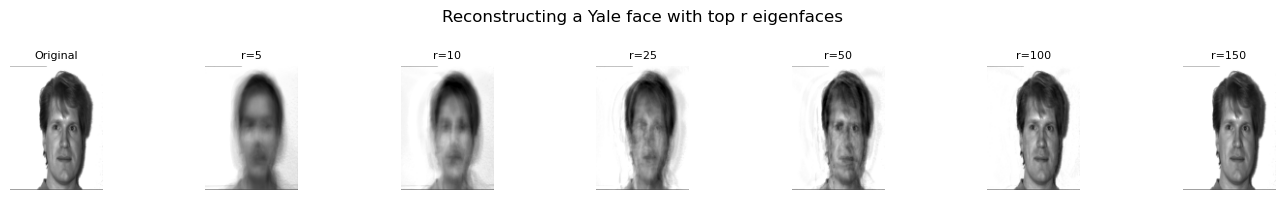

In [8]:
# %% [code] Reconstruction helper + demo

def reconstruct(img2d, U, mu, r):
    x = img2d.reshape(-1,1)
    a = U[:,:r].T @ (x-mu)
    xhat = mu + U[:,:r] @ a
    return np.clip(xhat.reshape(img2d.shape), 0, 1)

# Demo with a Yale face
face_img = faces[0]   # subject01, centerlight
max_r = U.shape[1]
rs = [r for r in [5, 10, 25, 50, 100, 150] if r <= max_r]
recons = [face_img] + [reconstruct(face_img, U, mu, r) for r in rs]
show_grid(recons, titles=['Original']+[f'r={r}' for r in rs], ncols=len(recons),
          suptitle='Reconstructing a Yale face with top r eigenfaces')

## 4) Upload YOUR face!

Now for the fun part. Upload a **photo of yourself** (or any face photo) and see how the eigenfaces approximate it.

The eigenfaces form an orthonormal basis for the "face subspace" $W$. When we project your face onto $W$:

$$\hat{x}_{\text{you}} = \mu + U_r U_r^T (x_{\text{you}} - \mu)$$

we get the **best approximation of your face** as a linear combination of eigenfaces. Since the Yale basis captures real human face variation, your reconstruction should look recognizable — especially as $r$ increases!

Upload your image file next to this notebook (or to the Colab file panel), then set `filename` below.

In [ ]:
# %% [code] Upload your face and reconstruct

# On Colab: pops up a file chooser dialog
# On local Jupyter: set filename to your image file
try:
    from google.colab import files
    print("Click 'Choose Files' to upload your photo:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
except ImportError:
    filename = 'selfie.jpg'   # <-- local Jupyter: change to your image file

try:
    img = io.imread(filename)
    img = to_gray01(img)
    img = transform.resize(img, (H, W), anti_aliasing=True)
    max_r = U.shape[1]
    rs = [r for r in [5, 10, 25, 50, 100, 150] if r <= max_r]
    recons = [img] + [reconstruct(img, U, mu, r) for r in rs]
    show_grid(recons, titles=['Original']+[f'r={r}' for r in rs], ncols=4,
              suptitle=f'Approximating YOUR face with eigenfaces')
except FileNotFoundError:
    print(f"File '{filename}' not found. Upload your photo and re-run this cell.")

## 5) Cross‑domain reconstruction (coffee)

Here is where the **subspace** idea really shows its power (and limitations).

The eigenfaces span a subspace $W$ that was **learned from faces**. When we project a non-face image (like coffee) onto $W$, we get the **closest point in the face subspace** — the best approximation using only face-like patterns.

$$\hat{x}_{\text{coffee}} = \mu + \text{proj}_W(x_{\text{coffee}} - \mu)$$

Compare this to your face reconstruction above. The coffee image is far from the face subspace, so the error $\|x - \hat{x}\|$ stays large even as $r$ increases.

In [ ]:
# %% [code] Coffee reconstruction
coffee = transform.resize(to_gray01(data.coffee()), (H, W))
max_r = U.shape[1]
rs = [r for r in [5, 10, 25, 50, 100, 150] if r <= max_r]
recons = [coffee] + [reconstruct(coffee, U, mu, r) for r in rs]
show_grid(recons, titles=['Original']+[f'r={r}' for r in rs], ncols=4,
          suptitle='Approximating coffee with eigenfaces')

## 6) Bonus: 2D projection scatter

We can visualize how the eigenface representation separates different people. By projecting every training image onto just the **first two eigenfaces** (PC1 and PC2), we get a 2D coordinate for each image:

$$\text{score}_i = U_2^T (x_i - \mu) \in \mathbb{R}^2$$

If the eigenfaces capture meaningful structure, images of the same person should cluster together in this 2D space. With 15 real people, we expect to see 15 distinct clusters.

In [ ]:
# %% [code] Scatter of scores on PC1–PC2
scores = (U[:,:2].T @ Xc)   # 2 × n
plt.figure(figsize=(6,5))
scatter = plt.scatter(scores[0], scores[1], s=15, c=labels, cmap='tab20')
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.colorbar(scatter, label='Subject ID')
plt.grid(True, ls=':')
plt.title('PC1–PC2 scores (each color = one person)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

## 7) Exercises
1. Plot **reconstruction error** vs. $r$ for a Yale face, your face, and coffee.  
2. Find the smallest $r$ that reaches **95% variance**; critique reconstructions at that $r$.  
3. Why does your face reconstruct better than coffee, even though your face was not in the training set?
4. (Optional) **Whitening**: check covariance of $\Sigma_r^{-1} U_r^T X_c$ is near identity.